<a href="https://colab.research.google.com/github/tahermatbouly/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Credit Card Fraud Detection**
##An AI tool that simulates an attack on a transaction then it detects and evaluate fraud and blocks it using classical ML and DL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#**Dealing with the data and Doing some Presprocessing**

In [2]:
data = pd.read_csv("/content/paysim.csv")

In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [6]:
data["step"]

,step
0,1
1,1
2,1
3,1
4,1
...,...
6362615,743
6362616,743
6362617,743
6362618,743


In [7]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
6362615,False
6362616,False
6362617,False
6362618,False


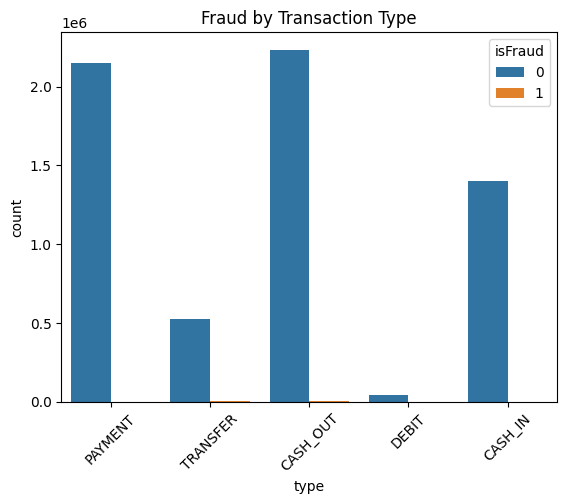

In [9]:
sns.countplot(x='type', hue='isFraud', data=data)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

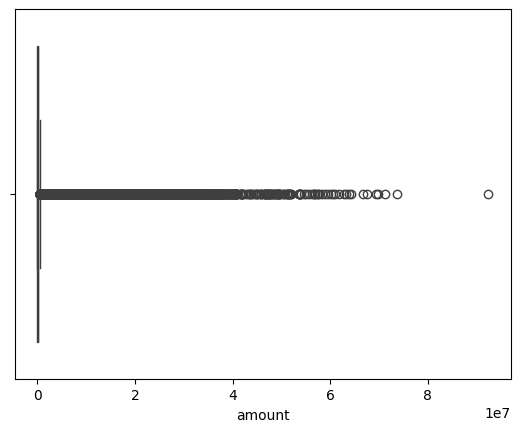

In [10]:
sns.boxplot(x=data['amount'])
plt.show()

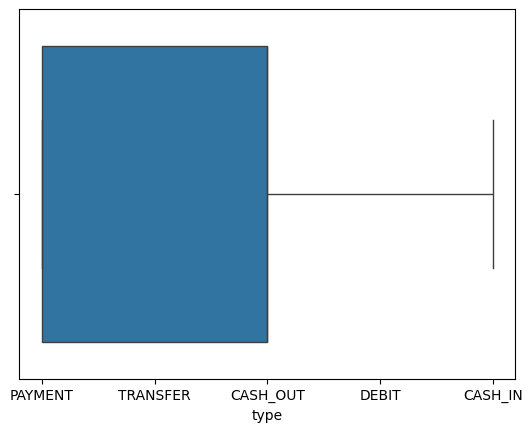

In [11]:
sns.boxplot(x=data['type'])
plt.show()

In [12]:
data['balance_diff_orig'] = data['newbalanceOrig'] - data['oldbalanceOrg']
data['balance_diff_dest'] = data['newbalanceDest'] - data['oldbalanceDest']

In [13]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,-11668.14,0.0


In [14]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,-11668.14,0.0


In [15]:
data = pd.get_dummies(data, columns=['type'], drop_first=True)

In [16]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,-9839.64,0.0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,-1864.28,0.0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,-181.00,0.0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-181.00,-21182.0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,-11668.14,0.0,False,False,True,False


In [17]:
hour = data["step"] % 24
day = data["step"] // 24
is_night = (hour < 6)

In [18]:
data['amount'].mean()

np.float64(179861.90354913071)

In [19]:
data['is_high_amount'] = (data['amount'] > data['amount'].mean()).astype(int)

In [20]:
data["is_high_amount"]

,is_high_amount
0,0
1,0
2,0
3,0
4,0
...,...
6362615,1
6362616,1
6362617,1
6362618,1


In [21]:
data.head(30)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0,-9839.64,0.00,False,False,True,False,0
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0,-1864.28,0.00,False,False,True,False,0
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0,-181.00,0.00,False,False,False,True,0
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0,-181.00,-21182.00,True,False,False,False,0
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0,-11668.14,0.00,False,False,True,False,0
5,1,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0,-7817.71,0.00,False,False,True,False,0
6,1,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0,-7107.77,0.00,False,False,True,False,0
7,1,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0,-7861.64,0.00,False,False,True,False,0
8,1,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0,-2671.00,0.00,False,False,True,False,0
9,1,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0,-5337.77,-1549.21,False,True,False,False,0


<Axes: xlabel='amount', ylabel='Count'>

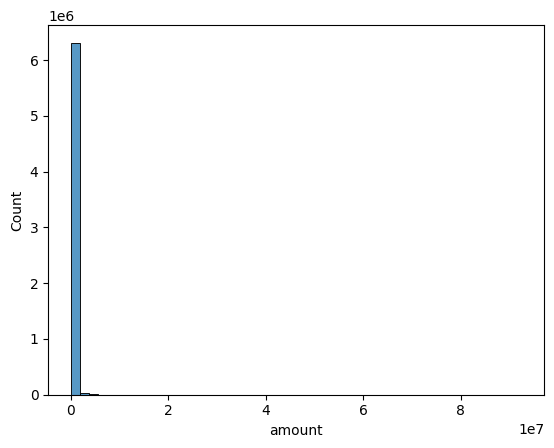

In [22]:
sns.histplot(data['amount'], bins=50)

#**Fraud is detected in high scaled data "amounts" , we are going to apply a normalization methid for the data which is Log Transformation**

In [23]:
data['amount_log'] = np.log1p(data['amount'])

In [24]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,-9839.64,0.0,False,False,True,False,0,9.194276
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,-1864.28,0.0,False,False,True,False,0,7.531166
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,-181.00,0.0,False,False,False,True,0,5.204007
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-181.00,-21182.0,True,False,False,False,0,5.204007
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,-11668.14,0.0,False,False,True,False,0,9.364703


<Axes: xlabel='amount_log', ylabel='Count'>

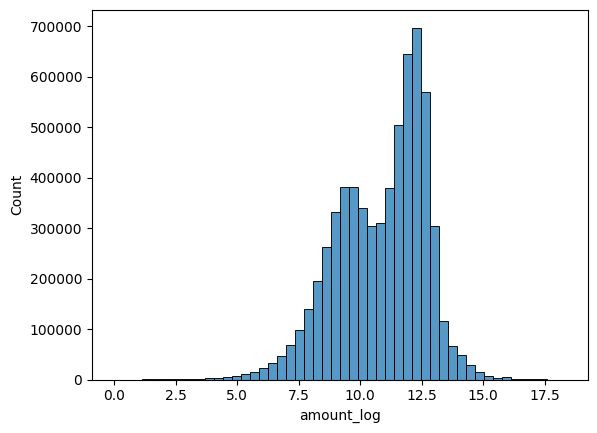

In [25]:
sns.histplot(data['amount_log'], bins=50)

#**Converting the categorical to int in the type columns**

In [26]:
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']] = \
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']].astype(int)

In [27]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,-9839.64,0.0,0,0,1,0,0,9.194276
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,-1864.28,0.0,0,0,1,0,0,7.531166
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,-181.00,0.0,0,0,0,1,0,5.204007
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-181.00,-21182.0,1,0,0,0,0,5.204007
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,-11668.14,0.0,0,0,1,0,0,9.364703


In [28]:
data['error_orig'] = abs(
    data['oldbalanceOrg'] - data['newbalanceOrig'] - data['amount']
)

In [29]:
data['error_dest'] = abs(
    data['newbalanceDest'] - data['oldbalanceDest'] - data['amount']
)

In [30]:
data.head(20)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0,-9839.64,0.00,0,0,1,0,0,9.194276,1.455192e-11,9839.64
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0,-1864.28,0.00,0,0,1,0,0,7.531166,1.136868e-12,1864.28
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0,-181.00,0.00,0,0,0,1,0,5.204007,0.000000e+00,181.00
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0,-181.00,-21182.00,1,0,0,0,0,5.204007,0.000000e+00,21363.00
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0,-11668.14,0.00,0,0,1,0,0,9.364703,0.000000e+00,11668.14
5,1,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0,-7817.71,0.00,0,0,1,0,0,8.964275,9.094947e-13,7817.71
6,1,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0,-7107.77,0.00,0,0,1,0,0,8.869085,1.091394e-11,7107.77
7,1,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0,-7861.64,0.00,0,0,1,0,0,8.969878,1.364242e-11,7861.64
8,1,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0,-2671.00,0.00,0,0,1,0,0,8.300370,1.353360e+03,4024.36
9,1,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0,-5337.77,-1549.21,0,1,0,0,0,8.582751,3.637979e-12,6886.98


In [31]:
data['high_risk_transaction'] = (
    (data['type_TRANSFER'] == 1) &
    (data['is_high_amount'] == 1)
).astype(int)

In [32]:
data.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,...,0.0,0,0,1,0,0,9.194276,1.455192e-11,9839.64,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,...,0.0,0,0,1,0,0,7.531166,1.136868e-12,1864.28,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,...,0.0,0,0,0,1,0,5.204007,0.000000e+00,181.00,0
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,...,-21182.0,1,0,0,0,0,5.204007,0.000000e+00,21363.00,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,...,0.0,0,0,1,0,0,9.364703,0.000000e+00,11668.14,0


In [33]:
data.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [34]:
data.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,-9839.64,0.0,0,0,1,0,0,9.194276,1.455192e-11,9839.64,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,-1864.28,0.0,0,0,1,0,0,7.531166,1.136868e-12,1864.28,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0,-181.00,0.0,0,0,0,1,0,5.204007,0.000000e+00,181.00,0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,-181.00,-21182.0,1,0,0,0,0,5.204007,0.000000e+00,21363.00,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,-11668.14,0.0,0,0,1,0,0,9.364703,0.000000e+00,11668.14,0


In [35]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log,error_orig,error_dest,high_risk_transaction
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,2.123056e+04,1.242947e+05,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02,2.949093e-01,1.084087e+01,2.010925e+05,9.359907e+04,6.618877e-02
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,1.466433e+05,8.129391e+05,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01,4.560020e-01,1.814509e+00,6.066505e+05,4.350570e+05,2.486118e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+07,-1.306083e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.015044e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.502306e+00,2.954230e+03,1.164153e-10,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.122355e+01,6.867726e+04,5.123620e+03,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.491054e+05,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.224876e+01,2.496411e+05,4.342133e+04,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.915268e+06,1.056878e+08,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.834213e+01,9.244552e+07,7.588573e+07,1.000000e+00


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   step                   int64  
 1   amount                 float64
 2   oldbalanceOrg          float64
 3   newbalanceOrig         float64
 4   oldbalanceDest         float64
 5   newbalanceDest         float64
 6   isFraud                int64  
 7   isFlaggedFraud         int64  
 8   balance_diff_orig      float64
 9   balance_diff_dest      float64
 10  type_CASH_OUT          int64  
 11  type_DEBIT             int64  
 12  type_PAYMENT           int64  
 13  type_TRANSFER          int64  
 14  is_high_amount         int64  
 15  amount_log             float64
 16  error_orig             float64
 17  error_dest             float64
 18  high_risk_transaction  int64  
dtypes: float64(10), int64(9)
memory usage: 922.3 MB


In [37]:
data = data.dropna()

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   step                   int64  
 1   amount                 float64
 2   oldbalanceOrg          float64
 3   newbalanceOrig         float64
 4   oldbalanceDest         float64
 5   newbalanceDest         float64
 6   isFraud                int64  
 7   isFlaggedFraud         int64  
 8   balance_diff_orig      float64
 9   balance_diff_dest      float64
 10  type_CASH_OUT          int64  
 11  type_DEBIT             int64  
 12  type_PAYMENT           int64  
 13  type_TRANSFER          int64  
 14  is_high_amount         int64  
 15  amount_log             float64
 16  error_orig             float64
 17  error_dest             float64
 18  high_risk_transaction  int64  
dtypes: float64(10), int64(9)
memory usage: 922.3 MB


In [39]:
X = data.drop(['isFraud', 'isFlaggedFraud'], axis=1)
y = data['isFraud']

In [40]:
print(X.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
       'is_high_amount', 'amount_log', 'error_orig', 'error_dest',
       'high_risk_transaction'],
      dtype='object')


In [41]:
print(y)

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5090096, 17)
(1272524, 17)
(5090096,)
(1272524,)
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


##Solving Calss Imbalance

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [45]:
print(y_train.value_counts())
print(y_train_res.value_counts())

isFraud
0    5083526
1       6570
Name: count, dtype: int64
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

#**First Model Logistic Regression Model**

In [47]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res_scaled, y_train_res)

LogisticRegression(max_iter=1000)

In [48]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
[[1214050   56831]
 [     52    1591]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.97      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.96      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC-AUC: 0.9936842823498073


#**After Training the First Model which is Logisitc Regression**
### it made good results in predecting fraud as it almost detected all of it but it detected some legit transactions as fraud wich is shown in the persicion

In [51]:
# Trying More than threeshold to enhance the performance

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_prob_lr > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1270881
           1       0.02      0.99      0.03      1643

    accuracy                           0.92   1272524
   macro avg       0.51      0.96      0.50   1272524
weighted avg       1.00      0.92      0.96   1272524


Threshold = 0.4
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.02      0.98      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.94      0.97   1272524


Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.97      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.96      0.52   1272524
weighted avg       1.00